(streaming_tick_data)=

# Streaming variational inference on high-frequency tick data

:::{post} August 2026
:tags: variational inference, minibatch, out-of-core, hierarchical model, time series
:category: advanced, tutorial
:author: Yicheng Yang
:::

Financial tick data outgrows memory quickly: one month of Binance aggregated
trades for a single liquid pair is roughly 28 million rows, and a modest
38-symbol universe (four majors over six months plus a one-month tail of 34
alt pairs) already exceeds 450 million rows — far more
than `pm.Minibatch` can hold resident on a 16 GB machine. This notebook fits a
hierarchical hurdle–Student-t model of *next-event price moves* to a dataset of
that scale by streaming minibatches from disk with pymc-extras'
{class}`~pymc_extras.variational.dataloader.DataLoader`. It tries to teach
three things that only show up on real data:

1. **When minibatch VI is even valid.** Two acceptance gates that most
   time-series models fail — and a model class that passes both.
2. **The full workflow at scale**: causal feature engineering, an on-disk
   global shuffle, streaming ADVI with `total_size` rescaling, and an online
   stopping rule.
3. **Honest reporting.** Mean-field variational inference produces some
   numbers you should trust and some you should not; with known ground truth
   we measure which are which instead of guessing.

The notebook runs in about a minute on synthetic data with known ground
truth — the streaming code is identical at any scale.

## Two gates: when minibatch VI is valid, and when it is worth it

Minibatch variational inference rests on one identity: if the likelihood
factors over rows given the parameters, then the batch log-likelihood scaled by
$N/B$ is an unbiased estimator of the full-data log-likelihood
{cite:p}`hoffman2013stochastic`. Two gates shaped this notebook's model — the
first is about *validity*, the second about whether streaming is doing any
real work — and they are worth internalizing before reaching for `total_size`
on your own data:

**Gate 1 — validity: the likelihood must factor over rows, sampled uniformly.**
No latent path coupling observations, no label shared across rows, and every
row given the same inclusion probability by the batching scheme (unequal
inclusion breaks the plain $N/B$ rescaling). This is exactly why the classic
stochastic volatility model of the {ref}`stochastic_volatility` notebook
*cannot* be minibatched: its latent volatility path ties every observation to
its neighbours, so a random subset of rows does not carry $B/N$ of the
log-likelihood. Any model whose rows share one outcome (for example, every tick
of a match sharing the final result) fails the same gate through
pseudo-replication — the effective sample size is the number of outcomes, not
the number of rows.

**Gate 2 — non-triviality: no low-dimensional sufficient statistics.** This
one is not about validity but about honesty of the *showcase*: a Normal
likelihood with per-cell means and variances collapses to per-cell
$(\sum y, \sum y^2, n)$, so one linear scan computes the exact posterior
inputs and "streaming inference" degenerates into a glorified `groupby` —
valid, but theater. What provably breaks the collapse: a Student-t likelihood,
a mixture (the hurdle below), and row-level continuous covariates through
nonlinear links.

The model below passes both gates, and each ingredient that makes it pass is
also substantively motivated by the data.

:::{include} ../extra_installs.md
:::

:::{note}
The {class}`~pymc_extras.variational.dataloader.DataLoader` merged into
pymc-extras after the v0.14.0 release. Until the next release, install
pymc-extras from `main`:
`pip install "pymc-extras @ git+https://github.com/pymc-devs/pymc-extras"`.
:::

In [1]:
import json
import logging
import os
import tempfile
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pymc as pm
import pytensor.tensor as pt

from pymc_extras.variational.dataloader import DataLoader, parquet_source

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 20260731
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
# the loss figures carry the fit story; keep the fit logger's lines out of the output
logging.getLogger("pymc").setLevel(logging.ERROR)
# pytensor's predictive path emits two benign internals warnings (a 0/0 inside its
# own allclose diagnostics; numba falling back to object mode for the python
# `random`); neither is actionable here, so they are filtered by origin
warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"pytensor\.tensor\.type")
warnings.filterwarnings("ignore", message=r"Numba will use object mode")

## The model: hierarchical hurdle–Student-t next-event returns

One row is one trade-to-trade transition $i$ on symbol $s$ at UTC hour $h$:
the return $y_i = 10^4 \, (\log p_{i+1} - \log p_i)$ in basis points, and the
move indicator $m_i = \mathbb{1}[y_i \neq 0]$. On real per-trade data roughly a
third of all transitions are *exactly* zero — the price simply does not move —
so a continuous likelihood alone would put zero probability mass on the single
most common outcome. The fix is a hurdle: model *whether* the price moves
separately from *how far* it moves given that it does.

$$
\begin{aligned}
m_i &\sim \text{Bernoulli}(\pi_i) \\
y_i \mid m_i = 1 &\sim \text{StudentT}(\nu,\ \mu_i,\ \sigma_i) \\
\operatorname{logit} \pi_i &= \kappa_0 + b^{(\kappa)}_s
  + B(h)^\top\!\left(c + b^{(\pi h)}_s\right)
  + \lambda_a a_i + \lambda_q q_i \\
\log \sigma_i &= \alpha_0 + b^{(\alpha)}_s
  + B(h)^\top\!\left(g + b^{(\sigma h)}_s\right)
  + (\beta_a + b^{(\beta a)}_s)\, a_i + \beta_q q_i \\
\mu_i &= \theta_d\, d_i + \theta_r\, \text{ylag}_i
\end{aligned}
$$

with raw covariates computed causally (from information available at trade
$i$): the trade sign $d_i$, log notional $q_i$, trailing 60-second activity
$a_i$, and the most recent previous nonzero return $\text{ylag}_i$. One
precision: $q$ and $a$ are then standardized with per-symbol constants
estimated over the full sample — a fixed affine map that changes the
parameterization, not the conditional law, and is shared by every arm below;
a deployed system would freeze these constants from a burn-in window. $B(h)$ is the first two sine/cosine harmonics of hour-of-day,
the standard way to encode intraday periodicity smoothly
{cite:p}`andersen1997intraday`; heavy-tailed Student-t noise for returns goes
back at least to {cite:t}`bollerslev1987conditionally`. All symbol effects
$b_s \sim \mathcal{N}(0, \tau)$ are partially pooled {cite:p}`gelman2006data`,
so a thin symbol borrows the global intraday shape where its own data run out —
that is the hierarchical payoff we will measure. They are parameterized
*centered*, deliberately: the familiar non-centered trick exists for data-poor
groups, and at $10^5$–$10^8$ rows per symbol every group here is data-rich.
The degrees of freedom are
shared across symbols, parameterized $\nu = 1 + \operatorname{softplus}(\eta)$;
the floor of 1 (rather than the more comfortable 2) leaves room for tails too
heavy to carry a finite variance — and the estimand below is chosen to stay
meaningful exactly there.

The reported estimand is **event-return dispersion on the event clock**:
$\pi_{s,h}$ together with the conditional-move 90% half-width
$\sigma_{s,h} \cdot t^{-1}_{0.95}(\nu)$. Quantile-based dispersion stays finite
for any $\nu > 0$; the familiar moment-based alternative does not survive this
dataset, as we will see.

## Synthetic data with known truth

Notebooks in this collection do not download data at build time, so the
executed path uses a seeded synthetic generator that mirrors the real corpus:
same schema, same hurdle structure, same heavy tails, twelve symbols with a
deliberately thin tail so shrinkage is visible. Because the truth is known,
recovery is checkable — and the likelihood, priors, and loader configuration
are line-for-line the ones used on the real corpus.

In [3]:
n_symbols = 12
counts = np.array(
    [90_700, 55_000, 40_000, 30_000, 24_000, 19_000, 15_000, 11_000, 8_000, 4_600, 1_800, 900]
)
thin = [10, 11]  # the two symbols with the least data

truth = {
    "kappa0": np.log(0.7 / 0.3),  # ~30% zero-move share at the baseline
    "c": np.array([0.25, -0.15, 0.10, 0.05]),
    "lambda_a": 0.35,
    "lambda_q": 0.20,
    "alpha0": np.log(0.05),  # baseline sigma ~ 0.05 bp, the real-data scale
    "g": np.array([0.20, -0.12, 0.08, 0.04]),
    "beta_a": 0.18,
    "beta_q": 0.12,
    "theta_d": 0.02,
    "theta_r": 0.25,
    "nu": 3.5,
}


def standardize(x, axis=0):
    return (x - x.mean(axis=axis, keepdims=True)) / x.std(axis=axis, keepdims=True)


z_truth = {
    "z_k": standardize(rng.standard_normal(n_symbols)),
    "z_ph": standardize(rng.standard_normal((n_symbols, 4))),
    "z_al": standardize(rng.standard_normal(n_symbols)),
    "z_sh": standardize(rng.standard_normal((n_symbols, 4))),
    "z_ba": standardize(rng.standard_normal(n_symbols)),
}

In [4]:
def hour_basis(hour):
    w = 2 * np.pi * np.asarray(hour, dtype=float) / 24.0
    return np.column_stack([np.sin(w), np.cos(w), np.sin(2 * w), np.cos(2 * w)])


sym = np.repeat(np.arange(n_symbols), counts)
n = len(sym)
hour = rng.integers(0, 24, size=n)
d = rng.choice([-1.0, 1.0], size=n)
a = standardize(rng.standard_normal(n))  # trailing activity (already standardized)
q = standardize(0.3 * a + np.sqrt(1 - 0.3**2) * rng.standard_normal(n))

B = hour_basis(hour)
logit_pi = (
    truth["kappa0"]
    + 0.30 * z_truth["z_k"][sym]
    + B @ truth["c"]
    + (B * (0.15 * z_truth["z_ph"][sym])).sum(1)
    + truth["lambda_a"] * a
    + truth["lambda_q"] * q
)
log_sigma = (
    truth["alpha0"]
    + 0.35 * z_truth["z_al"][sym]
    + B @ truth["g"]
    + (B * (0.12 * z_truth["z_sh"][sym])).sum(1)
    + (truth["beta_a"] + 0.10 * z_truth["z_ba"][sym]) * a
    + truth["beta_q"] * q
)

m = (rng.random(n) < 1 / (1 + np.exp(-logit_pi))).astype(np.int8)
t_draw = rng.standard_t(truth["nu"], size=n)

# sequential generation per symbol so ylag feeds back causally
y = np.zeros(n)
ylag = np.zeros(n)
sigma = np.exp(log_sigma)
for s in range(n_symbols):
    idx = np.flatnonzero(sym == s)
    last = 0.0
    for i in idx:
        ylag[i] = last
        if m[i]:
            y[i] = truth["theta_d"] * d[i] + truth["theta_r"] * last + sigma[i] * t_draw[i]
            last = y[i]

print(
    f"{n:,} rows, zero-move share {(m == 0).mean():.1%}, "
    f"median nonzero |y| {np.median(np.abs(y[m == 1])):.3f} bp"
)

300,000 rows, zero-move share 32.1%, median nonzero |y| 0.041 bp


The zero spike is the single most prominent feature of per-trade return data —
here is the synthetic version of the picture that forced the hurdle:

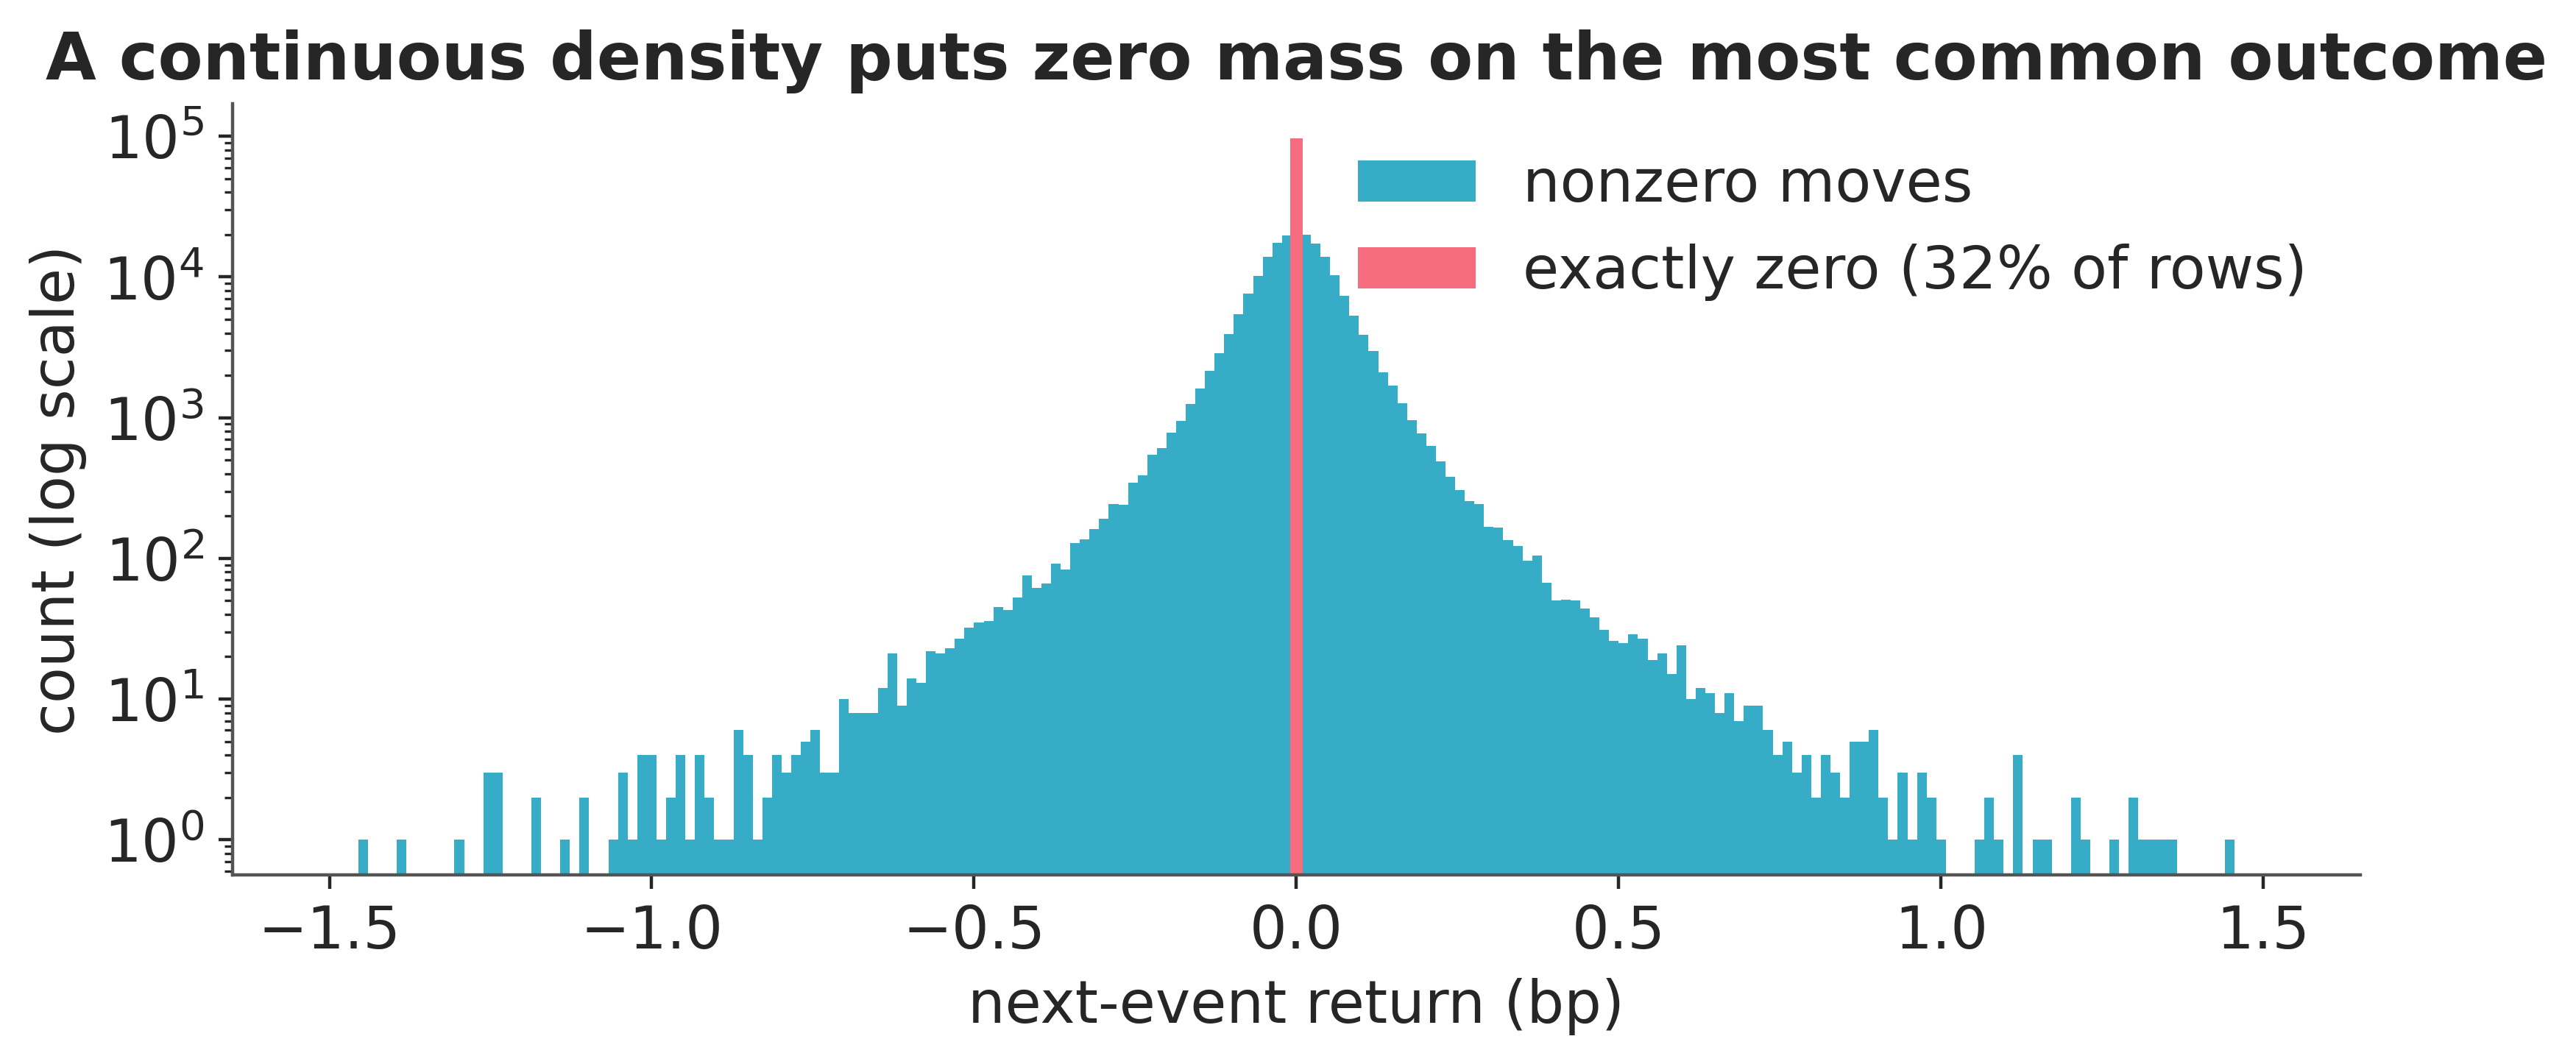

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
moves = y[m == 1]
ax.hist(moves, bins=201, range=(-1.5, 1.5), log=True, color="C0", label="nonzero moves")
ax.bar(
    [0.0],
    [(m == 0).sum()],
    width=0.02,
    color="C1",
    label=f"exactly zero ({(m == 0).mean():.0%} of rows)",
)
ax.set_xlabel("next-event return (bp)")
ax.set_ylabel("count (log scale)")
ax.set_title("A continuous density puts zero mass on the most common outcome")
ax.legend();

## The on-disk global shuffle

The trap in streaming ordered data is subtle enough to deserve its own
section. A bounded runtime shuffle buffer only *block*-shuffles a strongly
ordered stream: with tick data sorted by symbol and time, early optimization
steps would only ever see early dates and the first symbols, and an early
stopping decision would be biased by construction. The fix is to shuffle
**once, globally, on disk at ETL time**: every row gets a deterministic hash
key, rows are scattered across shards by that key, and each shard is sorted by
it. After that, sequential reads follow one fixed, data-independent uniform
permutation — replayed identically each epoch, which is single-shuffle SGD
semantics rather than fresh per-step subsampling — and the loader can run
with `shuffle=False` at full speed.

In [6]:
data_dir = tempfile.mkdtemp(prefix="ticks_")
table = pa.table(
    {
        "y_bp": y.astype(np.float32),
        "m": m,
        "d": d.astype(np.int8),
        "q_std": q.astype(np.float32),
        "a_std": a.astype(np.float32),
        "ylag_bp": ylag.astype(np.float32),
        "hour": hour.astype(np.int8),
        "sym": sym.astype(np.int16),
    }
)


def splitmix64(x):
    x = (x + np.uint64(0x9E3779B97F4A7C15)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    x = ((x ^ (x >> np.uint64(30))) * np.uint64(0xBF58476D1CE4E5B9)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    x = ((x ^ (x >> np.uint64(27))) * np.uint64(0x94D049BB133111EB)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    return x ^ (x >> np.uint64(31))


key = splitmix64(np.arange(n, dtype=np.uint64))
order = np.argsort(key, kind="stable")
n_shards = 8
for i in range(n_shards):
    part = table.take(order[i::n_shards])
    # Row groups are the loader's batches on the shuffle=False path, so size them here.
    pq.write_table(part, os.path.join(data_dir, f"shard_{i:03d}.parquet"), row_group_size=1024)

head = pq.read_table(os.path.join(data_dir, "shard_000.parquet")).slice(0, 10_000)
print(
    f"first 10k rows of one shard cover {len(np.unique(head['hour']))} hours "
    f"and {len(np.unique(head['sym']))} symbols"
)

first 10k rows of one shard cover 24 hours and 12 symbols


On the real corpus the same check is part of the ETL script's validation: the
head of any shard must already mix all 24 hours and nearly all symbols —
asserted on a sampled shard at build time and spot-checked on others, rather
than assumed. Note that the cell above is the pedagogical miniature — it sorts the
whole table in memory, which at corpus scale would need several gigabytes for
the keys and permutation alone. The published ETL is genuinely out-of-core:
pass one hash-scatters rows into shards with bounded row-group appends, pass
two sorts each shard independently, and no step ever holds the corpus.

## Streaming the model

With `shuffle=False` the `DataLoader` passes source blocks through verbatim —
one block per Parquet row group, in a frozen column order — which is why the
shards were written with `row_group_size=1024` above. The dataset size comes
from the Parquet metadata: `loader.total_size` is `N`, and `len(loader)` is
the number of batches per epoch, as for a torch dataloader. The model reads
one `pm.Data` placeholder; everything derived — the Fourier basis, the
integer symbol index — is computed inside the graph, so advancing the stream
is a single `set_value` per step.

In [7]:
columns = ["y_bp", "m", "d", "q_std", "a_std", "ylag_bp", "hour", "sym"]
loader = DataLoader(
    parquet_source(data_dir, columns=columns),
    batch_size=1024,
    shuffle=False,  # the shards are already globally shuffled on disk
    total_size="auto",
)
print(f"N = {loader.total_size:,} rows -> {len(loader):,} batches per epoch")

N = 300,000 rows -> 292 batches per epoch


One deliberate loader semantics to be precise about: on this path nothing is
dropped. Verbatim pass-through streams every row, and the last row group of
each shard is simply shorter than 1024. The `total_size` rescaling copes,
because PyMC scales the minibatch log-likelihood by `N / b` with `b` read
from the batch actually installed, so a short block is weighted up by exactly
its own size. Gate 1's equal-inclusion clause therefore holds for the full
corpus, with no tempering correction to track. (Only the shuffle-buffer path
drops a trailing partial batch; this notebook never uses it.)

In [8]:
def build_model(symbols, batch_init, total_size):
    coords = {"symbol": list(symbols), "harmonic": ["sin1", "cos1", "sin2", "cos2"]}
    with pm.Model(coords=coords) as model:
        batch = pm.Data("batch", batch_init)
        y_ = batch[:, 0]
        d_ = batch[:, 2]
        q_ = batch[:, 3]
        a_ = batch[:, 4]
        ylag_ = batch[:, 5]
        w = 2.0 * np.pi * batch[:, 6] / 24.0
        B_ = pt.stack([pt.sin(w), pt.cos(w), pt.sin(2 * w), pt.cos(2 * w)], axis=1)
        sym_ = pt.cast(batch[:, 7], "int32")

        kappa0 = pm.Normal("kappa0", 0.0, 5.0)
        c = pm.Normal("c", 0.0, 0.5, dims="harmonic")
        lambda_a = pm.Normal("lambda_a", 0.0, 0.5)
        lambda_q = pm.Normal("lambda_q", 0.0, 0.5)

        alpha0 = pm.Normal("alpha0", 0.0, 5.0)
        g = pm.Normal("g", 0.0, 0.3, dims="harmonic")
        beta_a = pm.Normal("beta_a", 0.0, 0.3)
        beta_q = pm.Normal("beta_q", 0.0, 0.3)

        theta_d = pm.Normal("theta_d", 0.0, 0.25)
        theta_r = pm.Normal("theta_r", 0.0, 0.25)

        tau_k, tau_ph, tau_al, tau_sh, tau_ba = (
            pm.LogNormal(name, 0.0, 1.5)
            for name in ["tau_k", "tau_ph", "tau_al", "tau_sh", "tau_ba"]
        )
        b_k = pm.Normal("b_k", 0.0, tau_k, dims="symbol")
        b_ph = pm.Normal("b_ph", 0.0, tau_ph, dims=("symbol", "harmonic"))
        b_al = pm.Normal("b_al", 0.0, tau_al, dims="symbol")
        b_sh = pm.Normal("b_sh", 0.0, tau_sh, dims=("symbol", "harmonic"))
        b_ba = pm.Normal("b_ba", 0.0, tau_ba, dims="symbol")

        eta = pm.Normal("eta", 5.0, 1.0)
        nu = pm.Deterministic("nu", 1.0 + pt.softplus(eta))

        logit_pi = (
            kappa0
            + b_k[sym_]
            + (B_ * (c + b_ph[sym_])).sum(axis=-1)
            + lambda_a * a_
            + lambda_q * q_
        )
        log_sigma = (
            alpha0
            + b_al[sym_]
            + (B_ * (g + b_sh[sym_])).sum(axis=-1)
            + (beta_a + b_ba[sym_]) * a_
            + beta_q * q_
        )
        mu = theta_d * d_ + theta_r * ylag_

        def hurdle_logp(value, logit_pi, mu, log_sigma, nu):
            # one coherent mixed distribution: an atom at exactly zero plus a
            # Student-t density off zero — the move indicator is value != 0,
            # never a separate parameter, so logp and random describe the SAME law
            sigma = pt.exp(log_sigma)
            t_ll = (
                pt.gammaln((nu + 1.0) / 2.0)
                - pt.gammaln(nu / 2.0)
                - 0.5 * pt.log(nu * np.pi)
                - log_sigma
                - (nu + 1.0) / 2.0 * pt.log1p(((value - mu) / sigma) ** 2 / nu)
            )
            moved = pt.neq(value, 0.0)
            return pt.where(moved, -pt.softplus(-logit_pi) + t_ll, -pt.softplus(logit_pi))

        def hurdle_random(logit_pi, mu, log_sigma, nu, rng=None, size=None):
            # simulate the same law: first whether the price moves, then how far
            pi = 1.0 / (1.0 + np.exp(-logit_pi))
            move = rng.random(size=size) < pi
            draw = mu + np.exp(log_sigma) * rng.standard_t(nu, size=size)
            return np.where(move, draw, 0.0)

        pm.CustomDist(
            "y_obs",
            logit_pi,
            mu,
            log_sigma,
            nu,
            logp=hurdle_logp,
            random=hurdle_random,
            observed=y_,
            total_size=total_size,
        )
    return model

Two implementation notes worth pausing on. The likelihood is a
{class}`~pymc.CustomDist` with a `logp`, not a `pm.Potential`: `CustomDist`
gives the term *observed-RV semantics*, which is what makes PyMC's own
`total_size` minibatch rescaling apply {cite:p}`kucukelbir2015automatic`. And
the hurdle's two logs are written with `softplus` —
$\log \pi = -\operatorname{softplus}(-x)$,
$\log(1-\pi) = -\operatorname{softplus}(x)$ — which is exact and stable at both
tails. The exact float comparison `value != 0` is safe here because the zeros
are *structural* — a transition either changes the price or it does not, and
the smallest genuine move on any listed tick grid sits dozens of orders of
magnitude above the float32 flush-to-zero threshold.

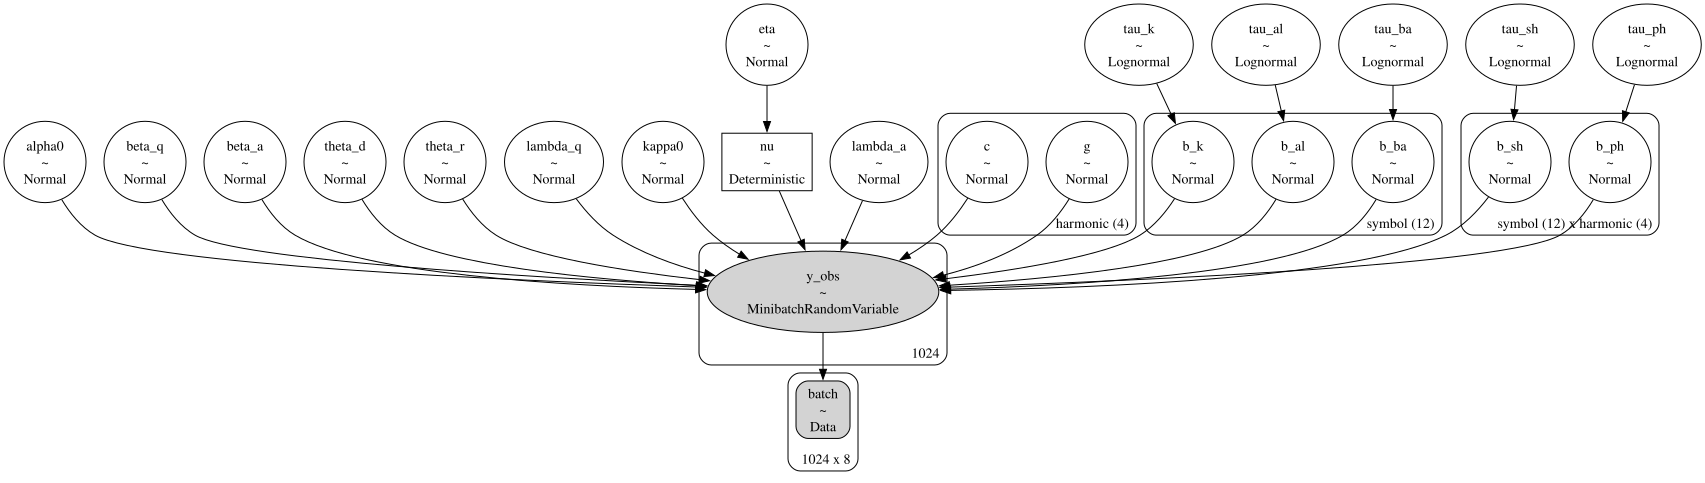

In [9]:
model = build_model(
    [f"SYM{i:02d}" for i in range(n_symbols)], next(iter(loader)), loader.total_size
)
pm.model_to_graphviz(model)

The plate diagram makes the two-link structure visible at a glance: five
partially pooled effect families on the symbol plate feeding two linear
predictors, one shared tail parameter, and a single observed node whose batch
dimension is whatever the placeholder currently holds.

In [10]:
class StreamAdvance:
    """pm.fit callback: put the next minibatch into the placeholder after each step."""

    def __init__(self, model, loader):
        self._shared = model["batch"]
        self._stream = self._endless(loader)

    @staticmethod
    def _endless(loader):
        while True:
            yield from loader

    def prime(self):
        self._shared.set_value(next(self._stream), borrow=True)

    def __call__(self, approx, losses, i):
        self._shared.set_value(next(self._stream), borrow=True)


stream = StreamAdvance(model, loader)
stream.prime()

with model:
    advi = pm.ADVI(random_seed=RANDOM_SEED)
advi.fit(6_000, obj_optimizer=pm.adam(learning_rate=0.02), callbacks=[stream], progressbar=False)
approx = advi.fit(
    2_500, obj_optimizer=pm.adam(learning_rate=0.005), callbacks=[stream], progressbar=False
)

The two-stage learning rate is not decoration: at a constant 0.02 the Adam
updates near the optimum are larger than the posterior standard deviations of
the sharpest parameters, so the mean jitters around the mode instead of
settling into it. Annealing was adopted after measuring exactly that on the
prototype.

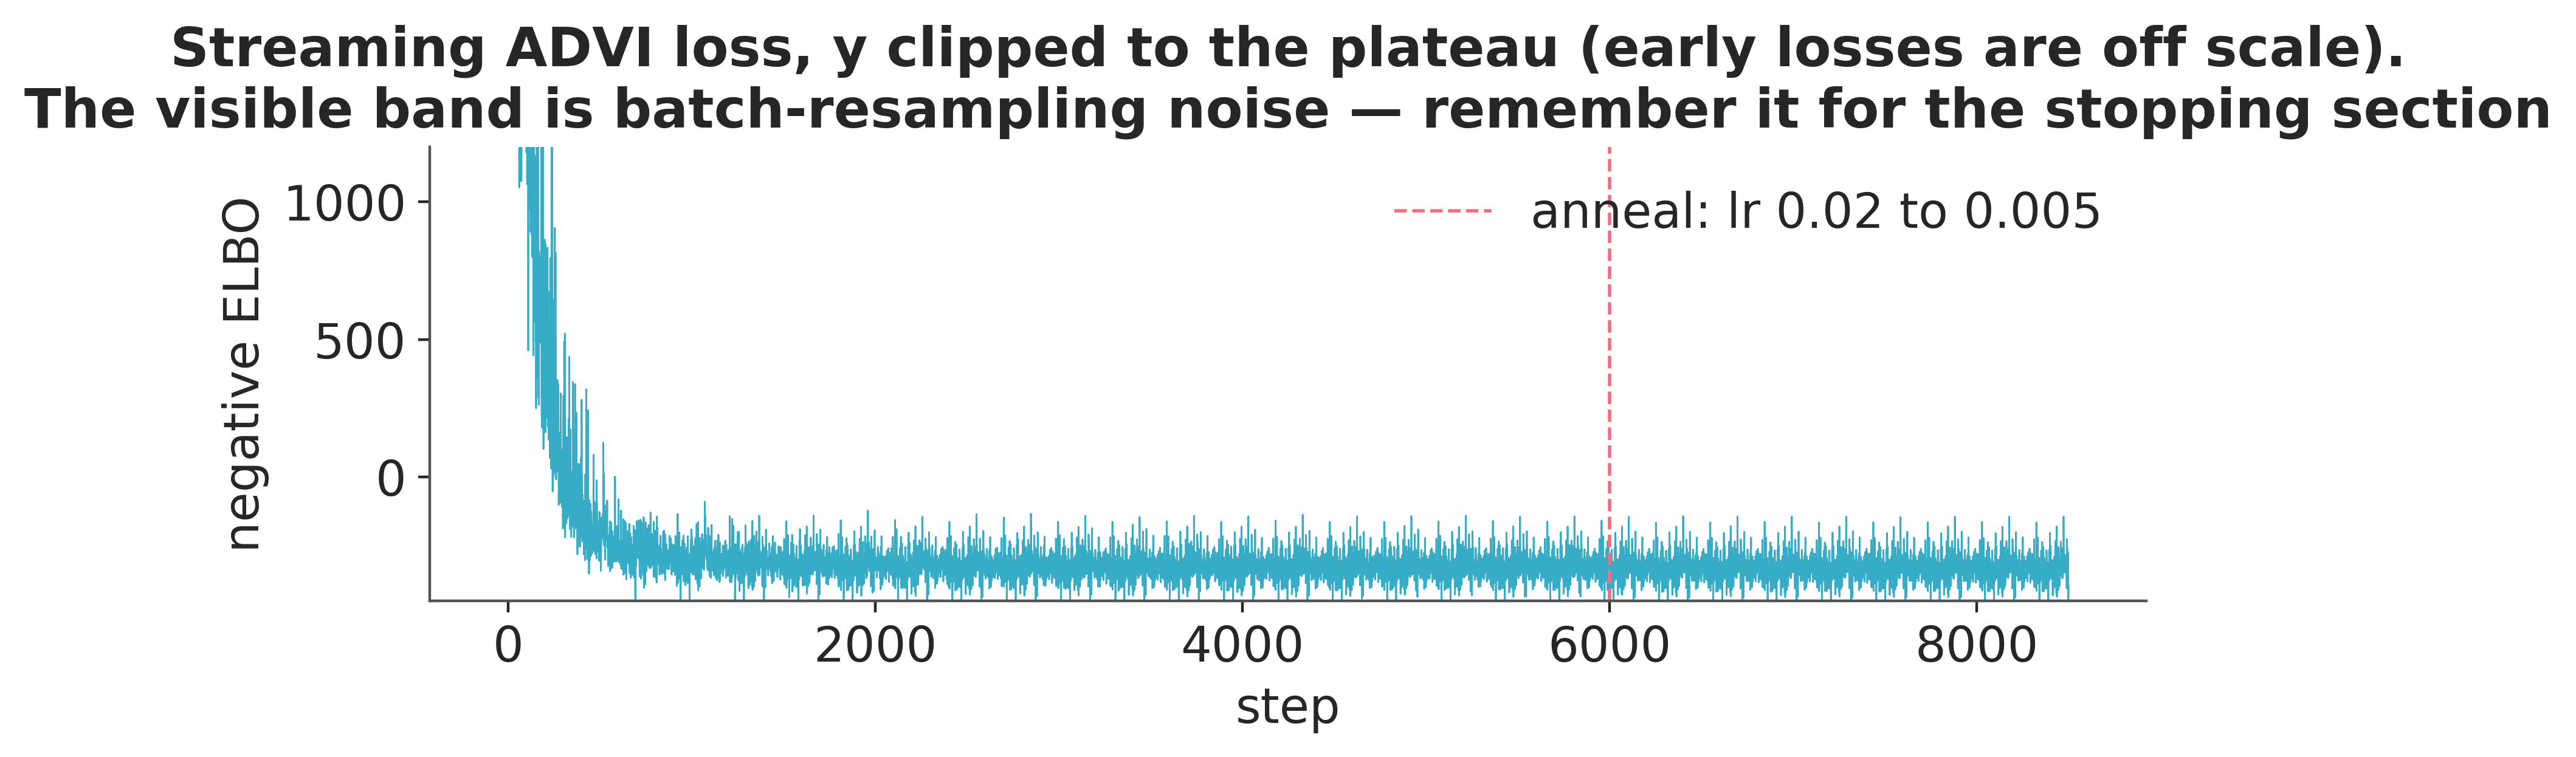

In [11]:
fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
ax.plot(approx.hist, lw=0.5)
ax.axvline(6_000, color="C1", ls="--", lw=1, label="anneal: lr 0.02 to 0.005")
ax.set_ylim(-450, 1200)
ax.set_xlabel("step")
ax.set_ylabel("negative ELBO")
ax.set_title(
    "Streaming ADVI loss, y clipped to the plateau (early losses are "
    "off scale).\nThe visible band is batch-resampling noise — "
    "remember it for the stopping section"
)
ax.legend();

## Did it recover the truth?

In [12]:
idata = approx.sample(2_000, random_seed=RANDOM_SEED)
post = idata.posterior

scalar_params = [
    "kappa0",
    "alpha0",
    "lambda_a",
    "lambda_q",
    "beta_a",
    "beta_q",
    "theta_d",
    "theta_r",
    "nu",
]
rows = {name: [float(post[name].mean()), float(post[name].std())] for name in scalar_params}
# the intercepts share a ridge with their group means; only the sums are identified
for icpt, b in [("kappa0", "b_k"), ("alpha0", "b_al"), ("beta_a", "b_ba")]:
    s = post[icpt] + post[b].mean("symbol")
    rows[f"{icpt} + mean({b})"] = [float(s.mean()), float(s.std())]
recovery = pd.DataFrame(rows, index=["mean", "sd"]).T
recovery["truth"] = [truth[p] for p in scalar_params] + [
    truth["kappa0"],
    truth["alpha0"],
    truth["beta_a"],
]
recovery["abs_error"] = (recovery["mean"] - recovery["truth"]).abs()
recovery.round(4)

,mean,sd,truth,abs_error
kappa0,0.5299,0.0052,0.8473,0.3174
alpha0,-1.6986,0.0036,-2.9957,1.2972
lambda_a,0.3384,0.0050,0.3500,0.0116
lambda_q,0.2094,0.0047,0.2000,0.0094
beta_a,0.1733,0.0030,0.1800,0.0067
beta_q,0.1435,0.0032,0.1200,0.0235
theta_d,0.0213,0.0002,0.0200,0.0013
theta_r,0.2505,0.0012,0.2500,0.0005
nu,3.5092,0.0249,3.5000,0.0092
kappa0 + mean(b_k),0.8299,0.0113,0.8473,0.0174


Read the table bottom-up. The raw intercepts look off by 0.3 and 1.3 — but a
global coefficient and the mean of its group effects are only *jointly*
identified: the likelihood constrains their sum, and the prior only weakly
splits it. The identified sums in the last three rows land within about one
hundredth of the truth, comparable to the other likelihood-identified rows.
The same translation ridge exists for every global-coefficient/group-effect
pair in this model (including the vector pairs $c$/$b^{(\pi h)}$ and
$g$/$b^{(\sigma h)}$, whose sums we spare you) — so raw split rows like
`kappa0`, `alpha0`, and `beta_a` are prior-dependent decompositions, not
estimates of their generating values; a sum-to-zero constraint on the symbol
effects is the standard reparameterization when the split itself matters.
Notice also what we did *not* print: z-scores against the truth. Some would
exceed 2, because the mean-field standard deviations in the third column are
razor-thin — a z-score against a point truth mixes the sampling noise of this
particular synthetic dataset with variational overconfidence along exactly
such ridges. This is the first appearance of a theme the notebook returns to
at full scale: a mean-field width is usable only where seed replication has
failed to disqualify it — replication can veto a width, never certify one.

The more interesting check is hierarchical: what happened to the per-symbol
effects of the two symbols with 1,800 and 900 rows?

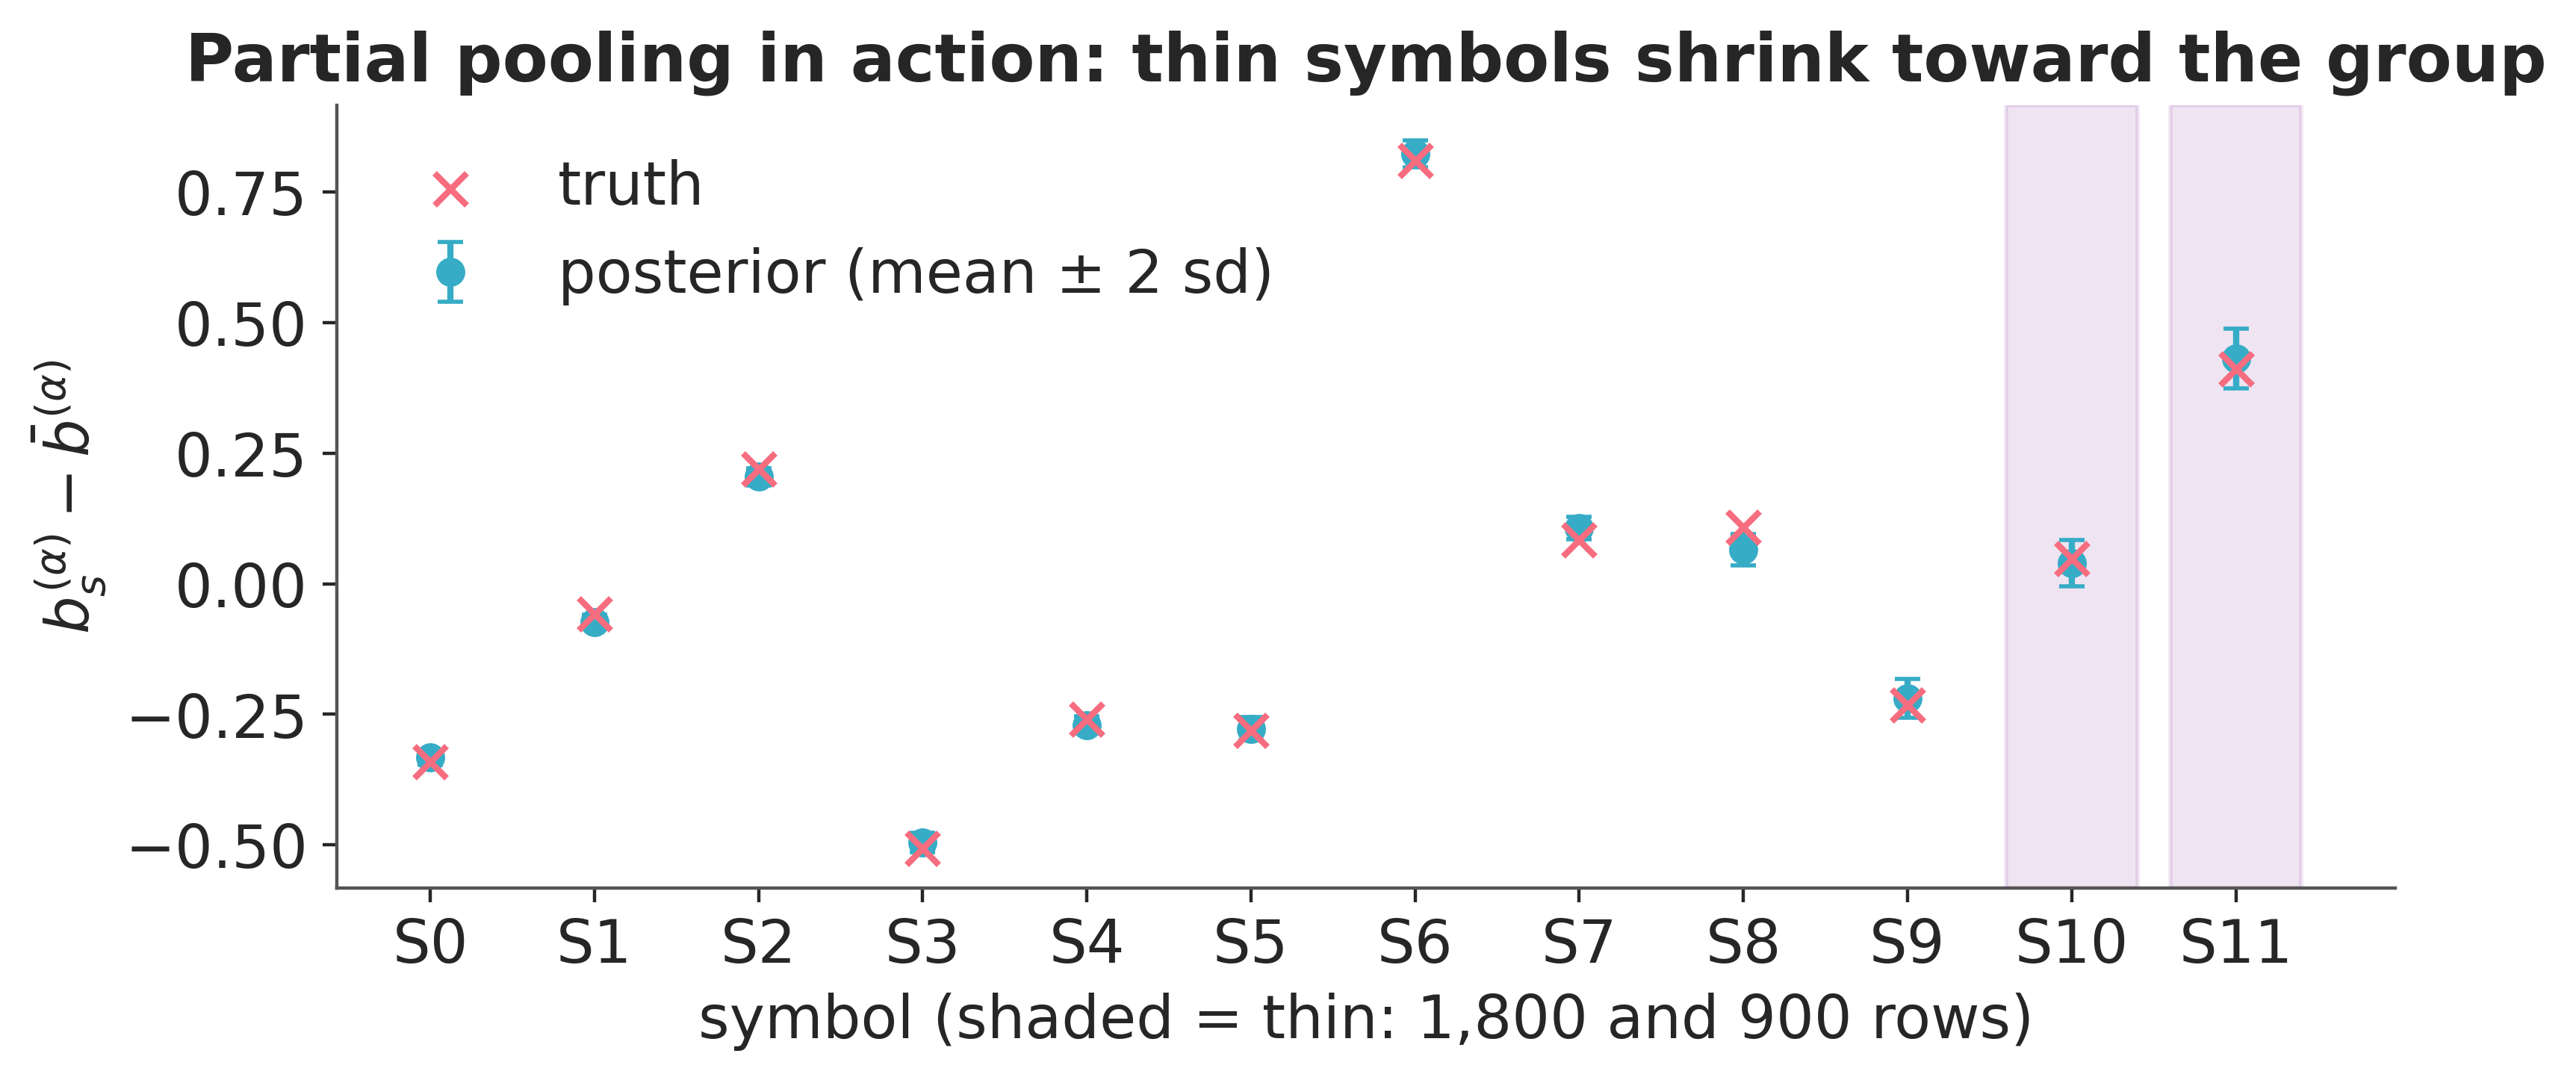

In [13]:
# plot the identified CONTRAST b - mean(b): the table above showed the absolute
# level belongs to a ridge with the intercept, so comparing raw b to raw truth
# would only display the arbitrary level split. Hand-rolled rather than
# az.plot_forest because the display is bespoke: truth overlay + thin shading.
bc = post["b_al"] - post["b_al"].mean("symbol")
b_mean = bc.mean(("chain", "draw")).values
b_sd = bc.std(("chain", "draw")).values
b_truth = 0.35 * z_truth["z_al"]  # the generator's scale times its z draws
b_truth = b_truth - b_truth.mean()

fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
x = np.arange(n_symbols)
ax.errorbar(
    x, b_mean, yerr=2 * b_sd, fmt="o", color="C0", capsize=3, label="posterior (mean ± 2 sd)"
)
ax.scatter(x, b_truth, marker="x", color="C1", s=60, zorder=3, label="truth")
for t in thin:
    ax.axvspan(t - 0.4, t + 0.4, color="C3", alpha=0.12)
ax.set_xticks(x)
ax.set_xticklabels([f"S{i}" for i in x])
ax.set_xlabel("symbol (shaded = thin: 1,800 and 900 rows)")
ax.set_ylabel(r"$b^{(\alpha)}_s - \bar{b}^{(\alpha)}$")
ax.set_title("Partial pooling in action: thin symbols shrink toward the group")
ax.legend();

The thin symbols' estimates are pulled toward zero and carry visibly wider
intervals — that is partial pooling doing exactly what it is for
{cite:p}`gelman2006data`. On the real corpus, where the thinnest symbol has
67,000 rows against BTC's 203 million, the same mechanism is what makes the
tail of the symbol universe estimable at all.

## Does it predict what matters?

A recovery table checks parameters; a posterior predictive check asks the
model to reproduce the data features it exists to describe. The `CustomDist`
carries a `random` implementation alongside its `logp`, so
{func}`~pymc.sample_posterior_predictive` works out of the box. The two
features that matter for this model are the exact-zero share and the heavy
conditional tail:

In [14]:
eval_batch = next(iter(loader))
model["batch"].set_value(eval_batch, borrow=True)  # same path the callback uses
with model:
    idata = pm.sample_posterior_predictive(
        idata,
        var_names=["y_obs"],
        random_seed=RANDOM_SEED,
        extend_inferencedata=True,
        progressbar=False,
    )

pp = idata.posterior_predictive["y_obs"].stack(sample=("chain", "draw")).values.T
y_eval = eval_batch[:, 0]

zero_share = (pp == 0).mean(axis=1)
med_nonzero = np.array([np.median(np.abs(d[d != 0])) for d in pp[:500]])
q99_nonzero = np.array([np.quantile(np.abs(d[d != 0]), 0.99) for d in pp[:500]])


def check_row(observed, draws):
    lo, hi = np.quantile(draws, [0.05, 0.95])
    return [observed, draws.mean(), lo, hi]


y_nonzero = np.abs(y_eval[y_eval != 0])
pd.DataFrame(
    [
        check_row((y_eval == 0).mean(), zero_share),
        check_row(np.median(y_nonzero), med_nonzero),
        check_row(np.quantile(y_nonzero, 0.99), q99_nonzero),
    ],
    columns=["observed", "pp mean", "pp 5%", "pp 95%"],
    index=["zero share", "median |move| (bp)", "q99 |move| (bp)"],
).round(3)

,observed,pp mean,pp 5%,pp 95%
zero share,0.315,0.331,0.308,0.355
median |move| (bp),0.042,0.041,0.038,0.044
q99 |move| (bp),0.324,0.340,0.281,0.411


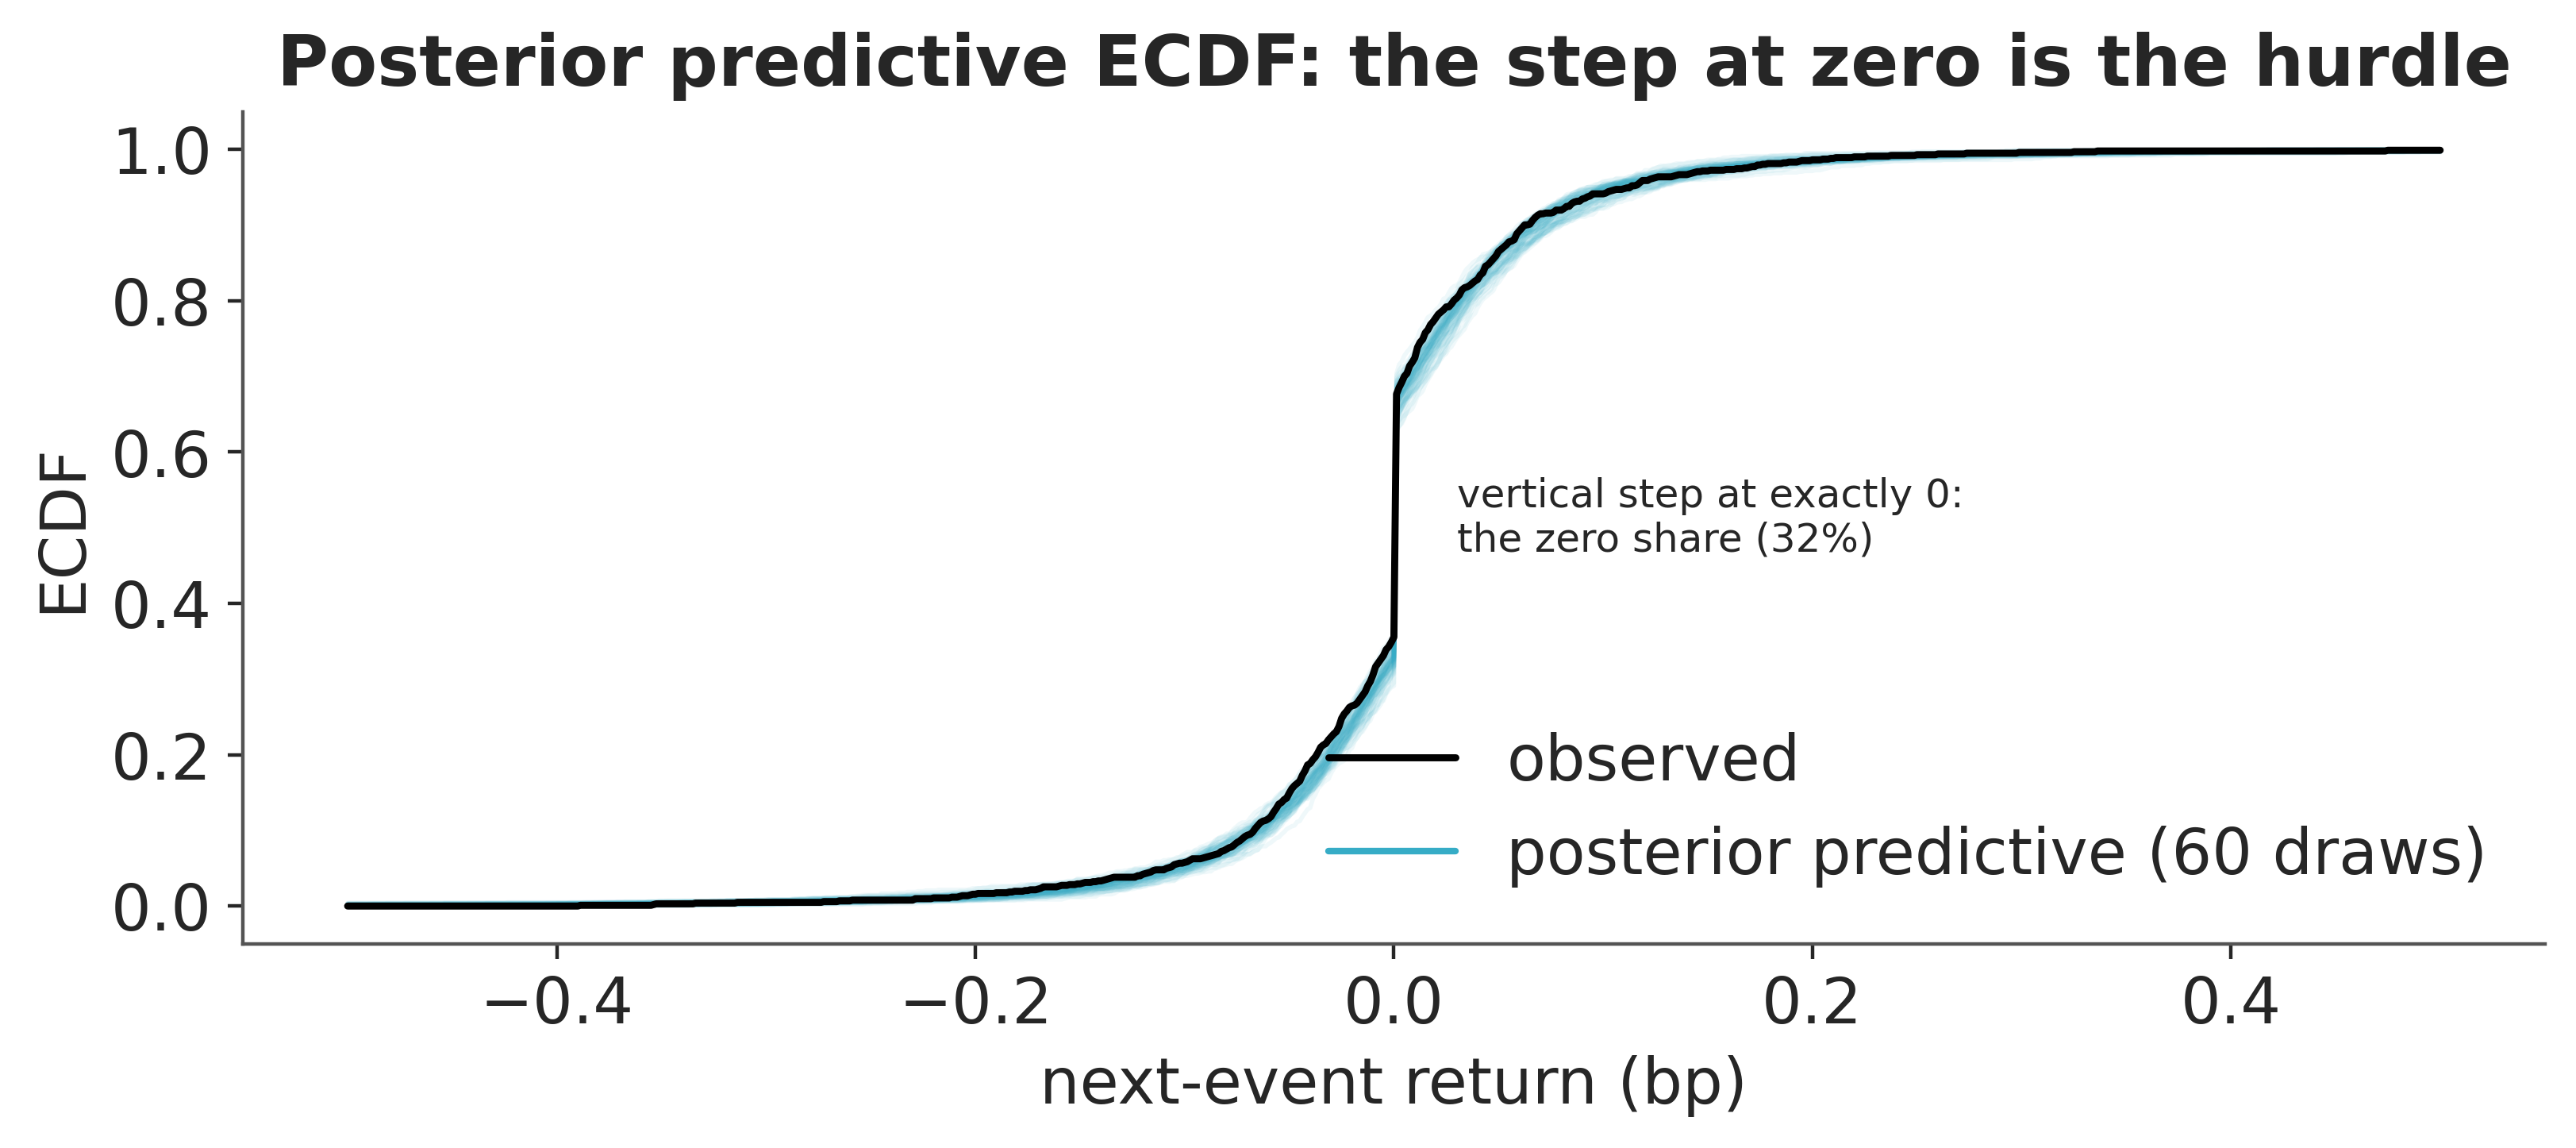

In [15]:
# hand-rolled ECDF: the bespoke feature is the annotated discrete jump at zero,
# which the predictive must reproduce in both location and height
fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
grid = np.linspace(-0.5, 0.5, 801)
for draw in pp[:60]:
    ax.plot(grid, np.searchsorted(np.sort(draw), grid) / draw.size, color="C0", alpha=0.08, lw=1)
ax.plot(
    grid, np.searchsorted(np.sort(y_eval), grid) / y_eval.size, color="k", lw=1.6, label="observed"
)
ax.plot([], [], color="C0", label="posterior predictive (60 draws)")
zero_jump = (y_eval == 0).mean()
below = (y_eval < 0).mean()
ax.annotate(
    f"vertical step at exactly 0:\nthe zero share ({zero_jump:.0%})",
    (0.03, below + zero_jump / 2),
    fontsize=9,
    ha="left",
    va="center",
)
ax.set_xlabel("next-event return (bp)")
ax.set_ylabel("ECDF")
ax.set_title("Posterior predictive ECDF: the step at zero is the hurdle")
ax.legend(loc="lower right");

Two of the three statistics sit inside their predictive 90% bands; the median
|move| lands at the band's edge (0.8% outside at full precision — the
3-decimal table hides it, so we say it here). Note also that this is an
in-sample adequacy check: the evaluation batch was seen during the fit; the
real-corpus scores later use shards the fits never touched. On real data one
further caveat would surface
here that the synthetic generator cannot show: real price changes are integer
multiples of the tick size, so the continuous Student-t's residual misfit
concentrates at |y| near one tick — visible as small stair-steps in the
observed ECDF that the smooth predictive cannot follow.

## Knowing when to stop — and how a stop rule can lie to you

A streamed ELBO trace is noisy — each value is a one-batch, one-Monte-Carlo
estimate — and eyeballing it does not scale to overnight runs. The stopping
rule originally proposed for PyMC in
[pymc#8384](https://github.com/pymc-devs/pymc/pull/8384)
standardizes each loss *improvement* by a robust running scale estimate and
feeds it to a one-sided CUSUM statistic {cite:p}`page1954continuous`, arming
itself only after `min_steps` — which on streaming fits should be at least
one full pass, since stopping before the model has seen every row once is
never evidence of convergence. The trap this section demonstrates was later
confirmed on real ADVI traces, and the revised implementation under review for
[pymc-extras#733](https://github.com/pymc-devs/pymc-extras/pull/733) is built on the windowed idea shown here, with horizons
that grow over the run and a second, practical-negligibility yardstick.

:::{admonition} The minibatch trap
:class: warning
Successive losses are evaluated on *different batches*, so the per-step noise
dwarfs the per-step improvement by orders of magnitude. A rule that
standardizes *raw* increments therefore concludes "improvement is
indistinguishable from zero" immediately upon arming, and fires a fixed
~$h/\kappa$ steps later regardless of whether the fit converged.
:::

The fix is as small as the trap is subtle: apply the identical rule to
*window means* of the loss, where averaging beats the batch-resampling noise
down by $\sqrt{k}$ and real improvement becomes visible again. We run both
against the same fit, as non-fatal shadow observers, and let them disagree:

In [16]:
class CheckLossConvergence:
    """One-sided CUSUM on robustly standardized loss improvements (pymc#8384)."""

    def __init__(self, kappa=0.25, h=20.0, halflife=200.0, min_steps=1000, z_clip=4.0):
        self.kappa, self.h, self.halflife = kappa, h, halflife
        self.min_steps, self.z_clip = min_steps, z_clip
        self._lam = float(np.exp(np.log(0.5) / halflife))
        self._prev_loss = self._prev_delta = self._scale = None
        self._S = 0.0

    def __call__(self, approx, loss, i):
        current = float(loss[-1])
        if not np.isfinite(current):
            return
        if self._prev_loss is None:
            self._prev_loss = current
            return
        delta, self._prev_loss = self._prev_loss - current, current
        if self._prev_delta is None:
            self._prev_delta = delta
            return
        abs_diff, self._prev_delta = abs(delta - self._prev_delta), delta
        if self._scale is None:
            self._scale = abs_diff
            return
        sigma = self._scale * np.sqrt(np.pi) / 2.0 + 1e-12
        self._scale = self._lam * self._scale + (1.0 - self._lam) * abs_diff
        z = float(np.clip(delta / sigma, -self.z_clip, self.z_clip))
        if i >= self.min_steps:
            self._S = max(0.0, self._S + (self.kappa - z))
        if self._S > self.h:
            raise StopIteration(f"converged at step {i} (S={self._S:.1f})")

In [17]:
class WindowMean:
    """Feed a stop rule the mean of every k losses instead of raw increments."""

    def __init__(self, monitor, k):
        self.monitor, self.k = monitor, k
        self._means = []

    def __call__(self, approx, losses, i):
        if len(losses) % self.k:
            return
        self._means.append(np.mean(losses[-self.k :]))
        self.monitor(approx, self._means, len(self._means))


class Shadow:
    """Record where a stop rule WOULD fire, without actually stopping the fit."""

    def __init__(self, callback):
        self.callback, self.stopped_at = callback, None

    def __call__(self, approx, losses, i):
        if self.stopped_at is None:
            try:
                self.callback(approx, losses, i)
            except StopIteration:
                self.stopped_at = len(losses)

In [18]:
loader2 = DataLoader(
    parquet_source(data_dir, columns=columns),
    batch_size=1024,
    shuffle=False,
    total_size="auto",
)
model2 = build_model(
    [f"SYM{i:02d}" for i in range(n_symbols)], next(iter(loader2)), loader2.total_size
)
stream2 = StreamAdvance(model2, loader2)
stream2.prime()
steps_per_epoch = len(loader2)  # batches per epoch, torch-style

k = 50
min_windows = -(-steps_per_epoch // k)  # ceil: never arm before one full pass
raw_shadow = Shadow(CheckLossConvergence(min_steps=steps_per_epoch))
win_shadow = Shadow(WindowMean(CheckLossConvergence(min_steps=min_windows), k))

with model2:
    advi2 = pm.ADVI(random_seed=RANDOM_SEED)
approx2 = advi2.fit(
    20_000,
    obj_optimizer=pm.adam(learning_rate=0.02),
    callbacks=[stream2, raw_shadow, win_shadow],
    progressbar=False,
)
assert (
    raw_shadow.stopped_at is not None and win_shadow.stopped_at is not None
), "a shadow rule never fired within the 20k-step budget; raise the budget"
win_stop = win_shadow.stopped_at  # Shadow records raw steps for both rules
print(
    f"raw increments: would stop at step {raw_shadow.stopped_at:,} "
    f"(loss there {approx2.hist[raw_shadow.stopped_at]:,.0f})"
)
print(
    f"window means (k={k}): would stop at step {win_stop:,} "
    f"(loss there {approx2.hist[win_stop]:,.0f}, final {approx2.hist[-1]:,.0f})"
)

raw increments: would stop at step 371 (loss there -122)
window means (k=50): would stop at step 4,650 (loss there -442, final -339)


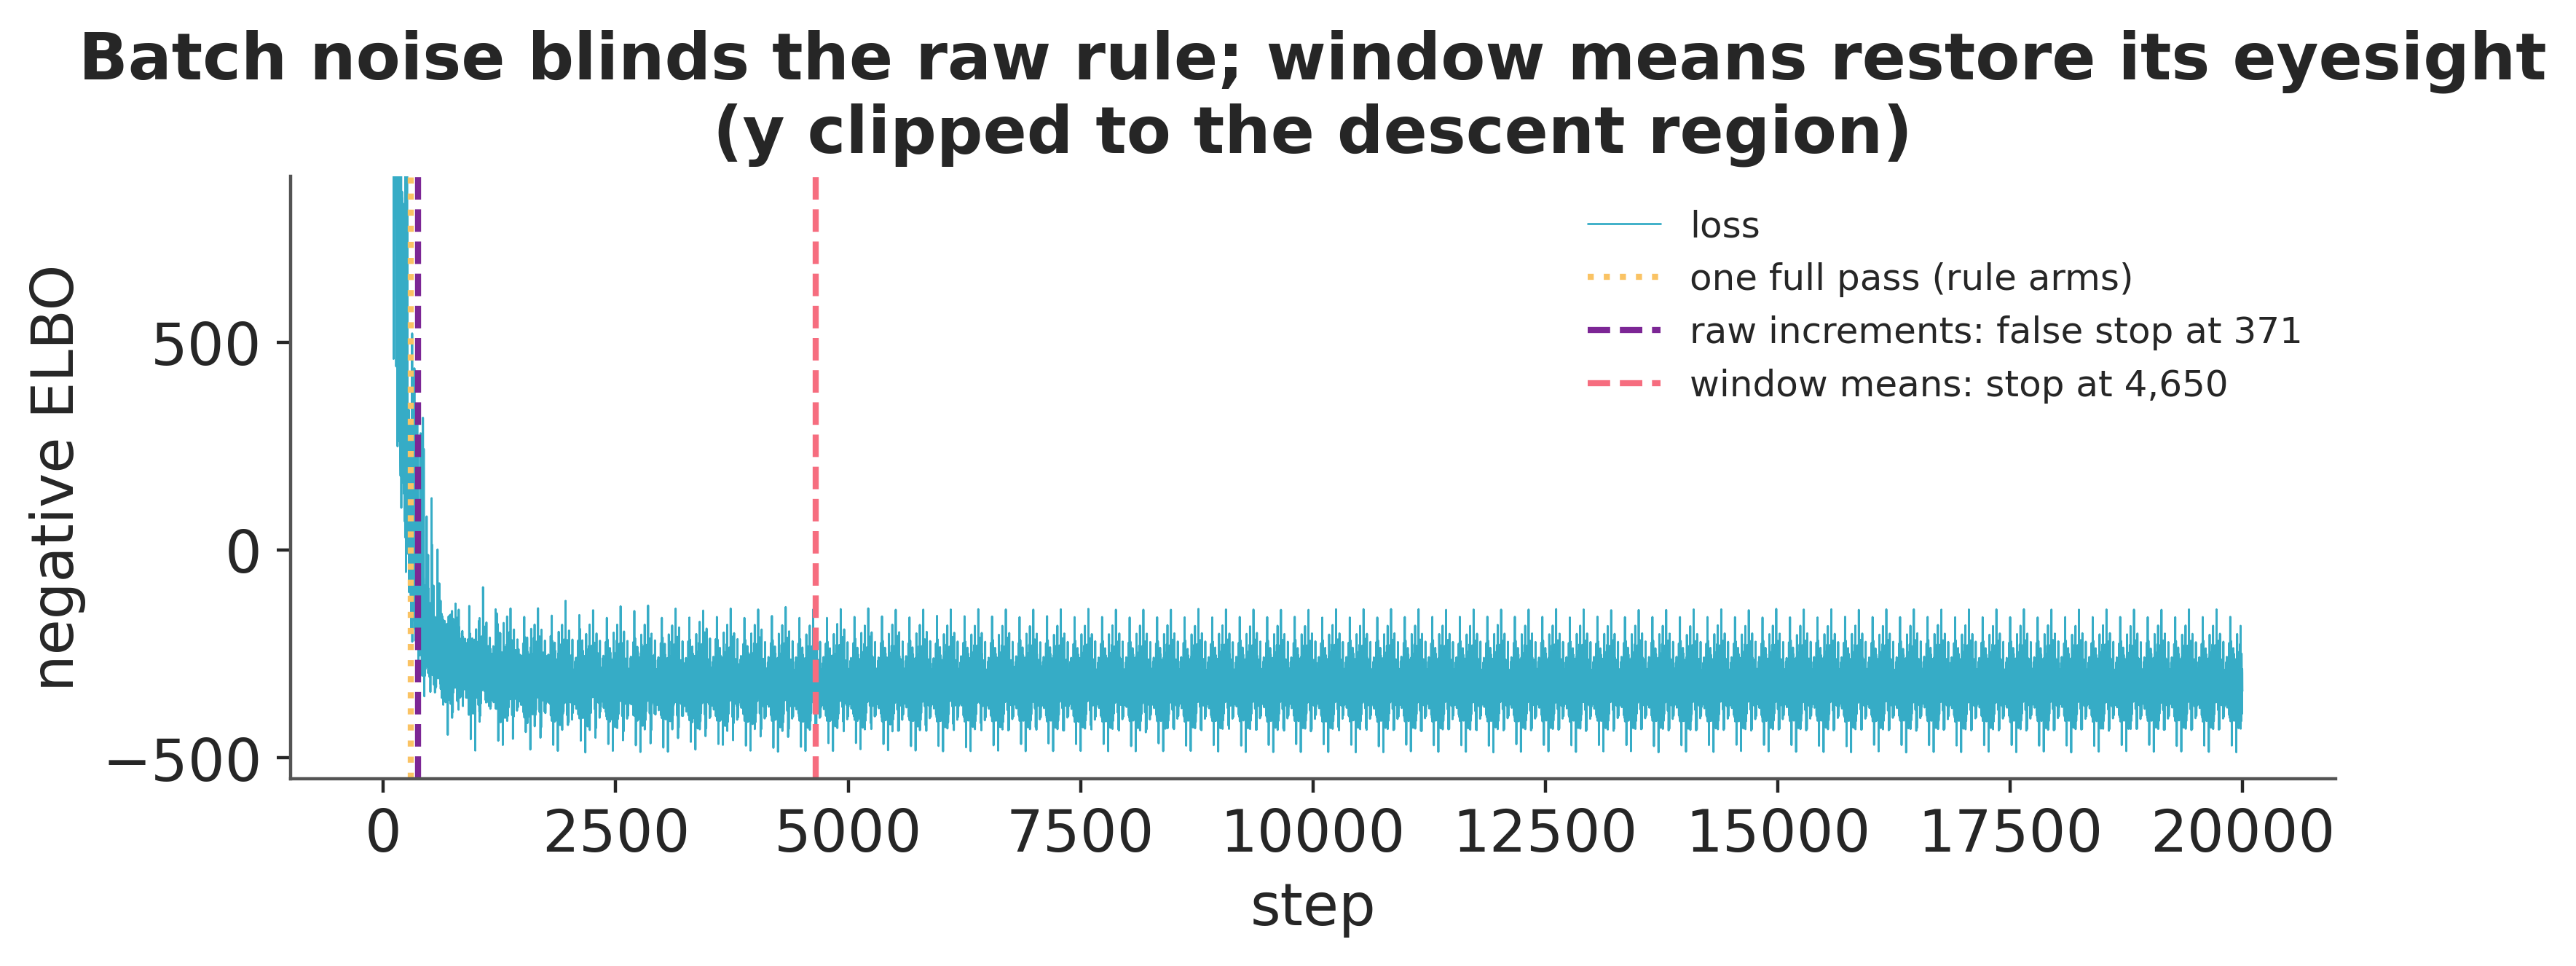

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.2), layout="constrained")
ax.plot(approx2.hist, lw=0.5, label="loss")
ax.axvline(steps_per_epoch, color="C2", ls=":", label="one full pass (rule arms)")
ax.axvline(
    raw_shadow.stopped_at,
    color="C3",
    ls="--",
    label=f"raw increments: false stop at {raw_shadow.stopped_at:,}",
)
ax.axvline(win_stop, color="C1", ls="--", label=f"window means: stop at {win_stop:,}")
ax.set_ylim(-550, 900)
ax.set_xlabel("step")
ax.set_ylabel("negative ELBO")
ax.set_title(
    "Batch noise blinds the raw rule; window means restore its eyesight\n"
    "(y clipped to the descent region)"
)
ax.legend(fontsize=9, loc="upper right");

The raw rule fires a fixed ~80 steps after arming with the loss still far from
its floor — a false stop that a fixed-budget run would silently avoid. The
windowed rule stops once per-window improvement falls below a quarter of the
window-noise scale, here capturing roughly 95% of the total loss descent at
under a quarter of the step budget. Two honest qualifications. First, what the
rule detects is a *loss plateau* — a necessary signal, not a proof that the
posterior has converged; the recovery and predictive checks earlier in the
notebook are the kind of independent evidence a stop should be paired with.
Second, the $h/\kappa$-window delay after a plateau is the rule's *nominal*
detection lag; clipping and the adaptive scale can move the actual hitting
time.

## Where the pieces live

:::{seealso}
The `DataLoader`/`parquet_source` used here merged in
[pymc-extras#698](https://github.com/pymc-devs/pymc-extras/pull/698). A
`Trainer` that wraps this notebook's callback pattern
([pymc-extras#710](https://github.com/pymc-devs/pymc-extras/pull/710)) and the
convergence monitor that grew out of the stopping section
([pymc-extras#733](https://github.com/pymc-devs/pymc-extras/pull/733)) are
under review.
:::

## Authors

* Authored by [Yicheng Yang](https://github.com/YichengYang-Ethan) in August
  2026 for the Google Summer of Code project *Streaming Variational Inference
  for Large Datasets* (PyMC / NumFOCUS).

## References

:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [20]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,pymc_extras

Last updated: Fri, 14 Aug 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.16.0

pytensor   : 3.1.3
pymc_extras: 0.13.1.dev4+gf8c50e5c6

arviz      : 1.2.0
json       : 2.0.9
logging    : 0.5.1.2
matplotlib : 3.10.9
numpy      : 2.4.6
pandas     : 3.0.3
pyarrow    : 25.0.0
pymc       : 6.1.0
pymc_extras: 0.13.1.dev4+gf8c50e5c6
pytensor   : 3.1.3

Watermark: 2.6.0



:::{include} ../page_footer.md
:::